# Notebook: Conceptos Clave de Machine Learning
Este notebook cubre varios conceptos fundamentales de Machine Learning, con secciones que incluyen descripción, explicación, ejercicio, solución y código documentado sobre un dataset sintético.

## Creación de Dataset Sintético
Generamos un dataset con variables categóricas, ordinales y numéricas, y una variable objetivo binaria.

In [ ]:
import numpy as np
import pandas as pd

np.random.seed(123)
n = 200
df = pd.DataFrame({
    'CatA': np.random.choice(['X', 'Y', 'Z'], size=n),
    'CatB': np.random.choice(['A', 'B'], size=n),
    'Ord': np.random.choice(['Low', 'Medium', 'High'], size=n),
    'Num1': np.random.randn(n),
    'Num2': np.random.rand(n) * 100,
    'target': np.random.choice([0, 1], size=n)
})
df.head()

,CatA,CatB,Ord,Num1,Num2,target
0,Z,B,Medium,1.501997,26.328104,1
1,Y,B,High,-0.188256,35.506513,0
2,Z,A,High,-0.740112,95.414397,1
3,Z,A,Low,-1.160529,46.113787,1
4,X,A,Medium,0.131529,68.489147,0


### 1. Codificación One-Hot
**Descripción:** Transformación de variables categóricas en variables binarias.

**Explicación:** Se crea una columna por cada nivel de la categoría y se asigna 1 o 0.

**Ejercicio:** Aplica codificación One-Hot a `CatA` y `CatB`.

**Solución:**

In [ ]:
from sklearn.preprocessing import OneHotEncoder

# Transformar nuestras variables categoricas a numericas
encoder = OneHotEncoder(drop='first')
cat_cols = ['CatA', 'CatB']
encoded = encoder.fit_transform(df[cat_cols])
encoded

#
df_encoded = pd.concat([df.drop(cat_cols, axis=1), pd.DataFrame(encoded.toarray(), columns=encoder.get_feature_names_out(cat_cols))], axis=1)

In [ ]:
df_encoded.head()

,Ord,Num1,Num2,target,CatA_Y,CatA_Z,CatB_B
0,Medium,1.501997,26.328104,1,0.0,1.0,1.0
1,High,-0.188256,35.506513,0,1.0,0.0,1.0
2,High,-0.740112,95.414397,1,0.0,1.0,0.0
3,Low,-1.160529,46.113787,1,0.0,1.0,0.0
4,Medium,0.131529,68.489147,0,0.0,0.0,0.0


### 2. Codificación de Etiquetas
**Descripción:** Asigna un entero a cada nivel de la categoría.

**Explicación:** OrdinalEncoder transforma categorías en 0,1,2,...

**Ejercicio:** Aplica codificación de etiquetas a todas las variables categóricas.

**Solución:**

In [ ]:
from sklearn.preprocessing import OrdinalEncoder

# Instanciando el transformador
encoder = OrdinalEncoder()
df_enc = df_encoded.copy()
df_enc[['Ord']] = encoder.fit_transform(df[['Ord']])
df_enc.head()

,Ord,Num1,Num2,target,CatA_Y,CatA_Z,CatB_B
0,2.0,1.501997,26.328104,1,0.0,1.0,1.0
1,0.0,-0.188256,35.506513,0,1.0,0.0,1.0
2,0.0,-0.740112,95.414397,1,0.0,1.0,0.0
3,1.0,-1.160529,46.113787,1,0.0,1.0,0.0
4,2.0,0.131529,68.489147,0,0.0,0.0,0.0


### 3. Escalado Numérico (StandardScaler)
**Descripción:** Normaliza las variables numéricas para media 0 varianza 1.

**Explicación:** `StandardScaler` ajusta media y desviación estándar.

**Ejercicio:** Escala `Num1` y `Num2`.

**Solución:**

### 4. Exactitud para el Árbol de Decisión
**Descripción:** Medida de aciertos sobre datos de validación.

**Explicación:** `accuracy_score` muestra proporción de predicciones correctas.

**Ejercicio:** Entrena un árbol y calcula exactitud.

**Solución:**

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Separar nuestros datos en X y y. Y en entrenamiento y prueba

X = df_enc.drop('target', axis=1)
y = df_enc['target']

# Separar conjunto de datos en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [ ]:
tree = DecisionTreeClassifier(random_state=12345)
# Ajustando el modelo de Decision Tree
tree.fit(X_train, y_train)

# Predicciones del modelo
y_pred = tree.predict(X_test)
# Calcular la exactitud
print('Accuracy:', accuracy_score(y_test, y_pred))

Accuracy: 0.625


### 5. Prueba de Consistencia
**Descripción:** Comparación con predicción constante.

**Explicación:** Frecuencia de clases vs. modelo vs. baseline constante.

**Ejercicio:** Mide frecuencia y compara con modelo constante.

**Solución:**

### 6. Equilibrio y Desequilibrio de Clases
Exploramos matriz de confusión, recall, precisión y F1.

#### 6.1 Matriz de Confusión

In [ ]:
from sklearn.metrics import confusion_matrix

# Matriz de confusión con categorias
confusion_matrix(y_test, y_pred, labels=[0, 1])

# Visualizar la matriz de confusion
pd.crosstab(y_test, y_pred, rownames=['Actual'], colnames=['Predicted'], margins=True)

Predicted,0,1,All
Actual,,,
0,12,9,21
1,6,13,19
All,18,22,40


#### 6.2 Recall

In [ ]:
from sklearn.metrics import recall_score

# Recall para el modelo
recall_score(y_test, y_pred)

0.6842105263157895

#### 6.3 Precisión

In [ ]:
from sklearn.metrics import precision_score
print('Precision:', precision_score(y_test, y_pred))

Precision: 0.5909090909090909


#### 6.4 Valor F1

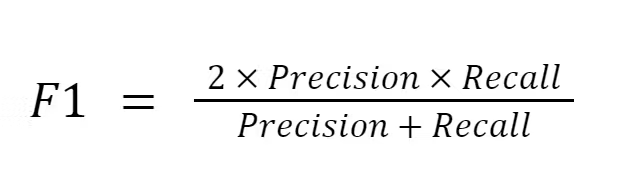

In [ ]:
from sklearn.metrics import f1_score
print('F1 Score:', f1_score(y_test, y_pred))

F1 Score: 0.6341463414634146


### 7. Manejo del Desbalanceo de Clases

In [ ]:
# 7.2 Manejo del desequilibrio de clases mediante sobremuestreo

import pandas as pd
from sklearn.utils import resample
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score

# 1. Reconstruir el DataFrame de entrenamiento uniendo características y etiqueta
#    X_train: DataFrame con las variables predictoras de entrenamiento
#    y_train: Series con la variable objetivo de entrenamiento
df_train = pd.concat([X_train, y_train.rename('target')], axis=1)

# 2. Separar la clase mayoritaria y minoritaria
major = df_train[df_train['target'] == 0]  # Ejemplares de la clase 0 (mayoría)
minor = df_train[df_train['target'] == 1]  # Ejemplares de la clase 1 (minoría)


# 3. Realizar sobremuestreo de la clase minoritaria
#    - replace=True: permite muestreo con reemplazo
#    - n_samples=len(major): igualar el número de muestras de la clase mayoritaria
#    - random_state=12345: para reproducibilidad
minor_upsampled = resample(
    minor,
    replace=True,
    n_samples=len(major),
    random_state=12345
)


# 4. Concatenar las clases original y sobremuestreada (balanceada)
train_up = pd.concat([major, minor_upsampled])

In [ ]:
# 5. Separar nuevamente en características (X_up) y etiqueta (y_up)
X_up = train_up.drop('target', axis=1)
y_up = train_up['target']

# 6. Crear y entrenar un modelo de regresión logística
model_up = LogisticRegression(
    solver='liblinear',  # recomendado para datasets pequeños
    random_state=12345
)
model_up.fit(X_up, y_up)

LogisticRegression(random_state=12345, solver='liblinear')

In [ ]:
# 7. Evaluar el modelo en el conjunto de prueba original
y_pred_up = model_up.predict(X_test)
f1_up = f1_score(y_test, y_pred_up)

# 8. Imprimir la métrica F1 resultante
print(f'F1 tras sobremuestreo: {f1_up:.3f}')

F1 tras sobremuestreo: 0.579


### 8. Métricas de Regresión
Creamos un dataset de regresión sintético y evaluamos MSE, RMSE, R2 y MAE.